In [ ]:
!pip install catboost --q

In [ ]:
import os
import pandas as pd
from google.colab import drive
from torch.cuda import is_available
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


drive.mount('/content/drive')
#!ls '/content/drive/MyDrive'
#!cp ЛЦТ/* {source_dir}
source_dir = '/content/drive/MyDrive/2025_09_LCT/data/source'
data_dir = dest_dir = '/content/drive/MyDrive/2025_09_LCT/data/auto'
#reviews_df = pd.read_csv(os.path.join(source_dir, 'reviews_banki-ru_25-09.csv'), index_col='id')
#reviews_df.head()
!ls {dest_dir}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
18_cat_classifier_full_data.cbm     category_classifier.cbm
batch_1f1e4fd8_083151.json	    joint_classification_model.cbm
batch_371d859b_093151.json	    sent_classifier_3_classes.cbm
batch_4e5cd182_115229.json	    sentences_1296_processed.csv
batch_60e237d8_112621.json	    sentences_1639_processed.csv
batch_65f0ccbd_084912.json	    sentences_1962_processed.csv
batch_91614183_081309.json	    sentences_2297_processed.csv
batch_aab1f84c_092526.json	    sentences_2622_processed.csv
batch_e57f8250_081819.json	    sentences_2969_processed.csv
batch_f13a2f63_090317.json	    sentences_314_processed.csv
batch_f68a2733_114044.json	    sentences_3282_processed.csv
batch_f858725c_104318.json	    sentences_3629_processed.csv
category_classifier_18_classes.cbm  sentences_656_processed.csv
category_classifier_30_classes.cbm  sentences_955_processed.csv


In [ ]:
!ls {source_dir}

 200_labeled_reviews_new_02.10.2025_v3.txt   categories.json
'600_labeled_reviews_02.10.2025 v4.txt'      last_300.xlsx
 answ_0_4.txt				     my_xlm_roberta_model
 batch_1a7200fe_120202.json		     review_links_banki-ru_25.09.json
 batch_f4a39c30_114343.json		     reviews_banki-ru_25-09.csv
 batch_f4a39c30_114431.json		     reviews_banki-ru_25-09.json
 categories_25.09.csv			     sentences_498_processed.csv
 categories_25.09.json			     sentences.csv
 categories.csv


In [ ]:
#200_labeled_reviews_new_02.10.2025_v3.txt
# 600_labeled_reviews_02.10.2025 v4.txt

In [ ]:
import json

def safe_load_json(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"Файл {file_path} не найден")
        return None
    except json.JSONDecodeError as e:
        print(f"Ошибка парсинга JSON: {e}")
        return None
    except Exception as e:
        print(f"Неизвестная ошибка: {e}")
        return None

def load_json_files(names):
    """
    Загружает все JSON файлы из указанной папки
    """
    all_data = []

    for filename in names:
        #if filename.endswith('.json'):
            file_path = os.path.join(source_dir, filename)
            try:
                #with open(file_path, 'r', encoding='utf-8') as f:
                    #data = json.load(f)
                    data = safe_load_json(file_path)
                    all_data.extend(data)
                    #all_data.append(data)
            except Exception as e:
                print(f"Ошибка при загрузке файла {filename}: {e}")

    return all_data
data = load_json_files(['200_labeled_reviews_new_02.10.2025_v3.txt', '600_labeled_reviews_02.10.2025 v4.txt'])
#data = load_json_files(['600_labeled_reviews_02.10.2025 v4.txt'])
len(data)
data[1]

{'id': '11907695',
 'sentences': [{'text': 'День добрый,привел по программе приведи друга 2 друзей вознагрождение не начислили,мой премиум менеджер мне грубит и не создаёт обращение по решению проблему уже месяц,не связывает с руководством отделения,прошу разобраться в проблеме и позвонить мне на телефон,премиум обслуживание очень не понятное',
   'category': ['Премиум-обслуживание',
    'Кэшбэк, промокоды, бонусы, акции, приведи друга',
    'Работа колл-центра и клиентского сервиса'],
   'main_category': 'Премиум-обслуживание',
   'sentiment': -1}]}

In [ ]:
from torch.cuda import is_available

RANDOM_STATE = RANDOM_SEED = 42
device = DEVICE = 'GPU' if is_available() else 'CPU'

CATEGORIES_D = pd.read_csv(os.path.join(source_dir, 'categories.csv')).set_index('id')['наименование'].to_dict()
NUM_CLASSES = len(CATEGORIES_D)
NUM_SENT_CLASSES = 3

CAT_CLASSIFIER_PATH = os.path.join(dest_dir,
                                   f'category_classifier_{NUM_CLASSES}_classes.cbm')

SENT_CLASSIFIER_PATH = os.path.join(dest_dir,
                                   f'sent_classifier_{NUM_SENT_CLASSES}_classes.cbm')

TEST_SIZE = .01

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
import json
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')


In [ ]:
'''def load_json_files(folder_path):
    """
    Загружает все JSON файлы из указанной папки
    """
    all_data = []

    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(folder_path, filename)
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    all_data.extend(data)
            except Exception as e:
                print(f"Ошибка при загрузке файла {filename}: {e}")

    return all_data

data = load_json_files(data_dir)
len(data)'''

'def load_json_files(folder_path):\n    """\n    Загружает все JSON файлы из указанной папки\n    """\n    all_data = []\n\n    for filename in os.listdir(folder_path):\n        if filename.endswith(\'.json\'):\n            file_path = os.path.join(folder_path, filename)\n            try:\n                with open(file_path, \'r\', encoding=\'utf-8\') as f:\n                    data = json.load(f)\n                    all_data.extend(data)\n            except Exception as e:\n                print(f"Ошибка при загрузке файла {filename}: {e}")\n\n    return all_data\n\ndata = load_json_files(data_dir)\nlen(data)'

In [ ]:
CATEGORIES_D = {
    1: "Дебетовые карты",
    2: "Кредитные карты",
    3: "Вклады",
    4: "Накопительные счета",
    5: "Потребительские кредиты",
    6: "Ипотека",
    7: "Страхование",
    8: "Денежные переводы, СБП",
    9: "Интернет-банк, мобильный банк и приложение",
    10: "Премиум-обслуживание",
    11: "Работа колл-центра и клиентского сервиса",
    12: "Безопасность и защита",
    13: "Общее впечатление о банке",
    14: "Кэшбэк, промокоды, бонусы, акции, приведи друга",
    15: "Прочие банковские услуги и сервисы",
    16: "Сравнение с конкурентами",
    17: "Тарифы, комиссии, прозрачность условий",
    18: "Эскалация и угроза жалоб"
}

# Обратный маппинг для поиска id по названию
CATEGORIES_REVERSE = {v: k for k, v in CATEGORIES_D.items()}
NUM_CLASSES = len(CATEGORIES_D)
CAT_CLASSIFIER_PATH = os.path.join(dest_dir,
                                   f'category_classifier_{NUM_CLASSES}_classes.cbm')

SENT_CLASSIFIER_PATH = os.path.join(dest_dir,
                                   f'sent_classifier_{NUM_SENT_CLASSES}_classes.cbm')
CAT_CLASSIFIER_PATH

'/content/drive/MyDrive/2025_09_LCT/data/auto/category_classifier_18_classes.cbm'

In [ ]:
import json
import pandas as pd
from typing import List, Dict

# Список категорий для маппинга

def load_reviews_json(data) -> pd.DataFrame:
    records = []
    for review in data:
        review_id = review['id']

        for idx, sentence in enumerate(review['sentences']):
            # Берем первую категорию как основную (или можно все обработать)
            categories = sentence['category']
            main_category = sentence.get('main_category', categories[0] if categories else 'Другие темы')

            # Маппим категорию в cat_id
            cat_id = CATEGORIES_REVERSE.get(main_category, 0)  # 0 для неизвестных
            if cat_id==0:
                if 'Кэшбэк, промокоды, бонусы, акции' in main_category:
                    cat_id = 14
                if 'Работа колл-центра' in main_category:
                    cat_id = 11
                main_category = CATEGORIES_D.get(cat_id, 0)
                break
                #if cat_id==0: print(sentence.get('main_category'))
            record = {
                'sentence_id': f"{review_id}_{idx:03d}",  # где idx - позиция предложения (0, 1, 2...)
                'review_id': review_id,
                'cat_id': cat_id,
                #'categories': categories,
                'main_category': main_category,
                'sentiment': sentence['sentiment'],
                'sentence_text': sentence['text']
            }
            records.append(record)

    df = pd.DataFrame(records)
    return df

# Использование
tr_val_df = load_reviews_json(data)
print(f"Загружено {len(tr_val_df)} предложений")
print(f"Уникальных отзывов: {tr_val_df['review_id'].nunique()}")
tr_val_df.head()

Загружено 5122 предложений
Уникальных отзывов: 448


,sentence_id,review_id,cat_id,main_category,sentiment,sentence_text
0,11476502_000,11476502,1,Дебетовые карты,0,Оформила дебетовую карту Юнион пей в январе 24г. Стоимость оформления 5000р!.
1,11476502_001,11476502,14,"Кэшбэк, промокоды, бонусы, акции, приведи друга",0,"На тот момент была акции, что вернем 5000р. при условии, что продержите остаток от 50 000,00 на карте или будут траты."
2,11476502_002,11476502,14,"Кэшбэк, промокоды, бонусы, акции, приведи друга",0,"Положить деньги нужно было в этот же день, что собственно говоря и было сделано."
3,11476502_003,11476502,14,"Кэшбэк, промокоды, бонусы, акции, приведи друга",-1,"26.04.24 был последний день начисления денежных средств, которых не начислили."
4,11476502_004,11476502,14,"Кэшбэк, промокоды, бонусы, акции, приведи друга",0,Условия акции Я выполнила.


In [ ]:
#set(tr_val_df['cat_id'].unique().tolist())==CATEGORIES_D.keys()

In [ ]:
'''def duplicate_multi_category_rows(df):
    """
    Дублирует строки с несколькими категориями, преобразуя списки в целые числа
    """
    duplicated_rows = []

    for idx, row in df.iterrows():
        # Преобразуем cat_id из списка в отдельные значения
        cat_ids = row['cat_id'] if isinstance(row['cat_id'], list) else [row['cat_id']]
        sentiments = row['sentiment'] if isinstance(row['sentiment'], list) else [row['sentiment']]

        # Если одна категория - оставляем как есть
        if len(cat_ids) == 1:
            new_row = row.copy()
            new_row['cat_id'] = int(cat_ids[0])
            new_row['sentiment'] = int(sentiments[0])
            duplicated_rows.append(new_row)
        else:
            # Если несколько категорий - создаем дубли для каждой
            for i, (cat_id, sent_id) in enumerate(zip(cat_ids, sentiments)):
                new_row = row.copy()
                new_row['cat_id'] = int(cat_id)
                new_row['sentiment'] = int(sent_id)
                new_row.name = f"{idx}_dup{i}"
                duplicated_rows.append(new_row)

    # Создаем новый DataFrame
    result_df = pd.DataFrame(duplicated_rows)
    return result_df

# Использование
tr_val_df_duplicated = duplicate_multi_category_rows(tr_val_df)
len(tr_val_df), len(tr_val_df_duplicated)'''

'def duplicate_multi_category_rows(df):\n    """\n    Дублирует строки с несколькими категориями, преобразуя списки в целые числа\n    """\n    duplicated_rows = []\n\n    for idx, row in df.iterrows():\n        # Преобразуем cat_id из списка в отдельные значения\n        cat_ids = row[\'cat_id\'] if isinstance(row[\'cat_id\'], list) else [row[\'cat_id\']]\n        sentiments = row[\'sentiment\'] if isinstance(row[\'sentiment\'], list) else [row[\'sentiment\']]\n\n        # Если одна категория - оставляем как есть\n        if len(cat_ids) == 1:\n            new_row = row.copy()\n            new_row[\'cat_id\'] = int(cat_ids[0])\n            new_row[\'sentiment\'] = int(sentiments[0])\n            duplicated_rows.append(new_row)\n        else:\n            # Если несколько категорий - создаем дубли для каждой\n            for i, (cat_id, sent_id) in enumerate(zip(cat_ids, sentiments)):\n                new_row = row.copy()\n                new_row[\'cat_id\'] = int(cat_id)\n            

In [ ]:
def split_data_by_review_id(df, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    df = df.copy()

    # Извлекаем review_id из sentence_id (часть до подчеркивания)
    df['review_id'] = df['sentence_id'].apply(lambda x: x.split('_')[0] if '_' in x else x)

    # Получаем уникальные review_id
    unique_review_ids = df['review_id'].unique()

    # Разделяем уникальные review_id на train/val
    train_review_ids, val_review_ids = train_test_split(
        unique_review_ids,
        test_size=test_size,
        random_state=random_state
    )

    # Создаем маски для разделения исходного DataFrame
    train_mask = df['review_id'].isin(train_review_ids)
    val_mask = df['review_id'].isin(val_review_ids)

    df_train = df[train_mask].copy()
    df_val = df[val_mask].copy()

    # Удаляем временный столбец
    df_train.drop('review_id', axis=1, inplace=True)
    df_val.drop('review_id', axis=1, inplace=True)

    print(f"Всего уникальных отзывов: {len(unique_review_ids)}")
    print(f"Train: {len(train_review_ids)} отзывов, {len(df_train)} предложений")
    print(f"Val: {len(val_review_ids)} отзывов, {len(df_val)} предложений")

    return df_train, df_val

train_df, val_df = split_data_by_review_id(tr_val_df)

Всего уникальных отзывов: 448
Train: 443 отзывов, 5077 предложений
Val: 5 отзывов, 45 предложений


In [ ]:
def balance_categories_across_splits(train_df, val_df):
    """
    Проверяет и балансирует категории между train и val
    Копирует отзывы с отсутствующими в train категориями из val в train
    """
    # Находим категории которые есть в val но нет в train
    train_categories = set(train_df['cat_id'].unique())
    val_categories = set(val_df['cat_id'].unique())
    missing_categories = val_categories - train_categories

    if not missing_categories:
        print("Все категории присутствуют в train, балансировка не требуется")
        return train_df, val_df

    print(f"Категории в val, отсутствующие в train: {missing_categories}")

    # Находим review_id отзывов в val с отсутствующими категориями
    val_df_temp = val_df.copy()
    val_df_temp['review_id'] = val_df_temp['sentence_id'].apply(lambda x: x.split('_')[0] if '_' in x else x)

    reviews_to_move = val_df_temp[val_df_temp['cat_id'].isin(missing_categories)]['review_id'].unique()

    print(f"Найдено отзывов для перемещения: {len(reviews_to_move)}")

    if len(reviews_to_move) == 0:
        return train_df, val_df

    # Создаем маски
    train_review_ids = train_df['sentence_id'].apply(lambda x: x.split('_')[0] if '_' in x else x).unique()
    move_mask = val_df_temp['review_id'].isin(reviews_to_move)

    # Перемещаем отзывы
    rows_to_move = val_df[move_mask]
    val_df_balanced = val_df[~move_mask]
    train_df_balanced = pd.concat([train_df, rows_to_move], ignore_index=True)

    print(f"Перемещено {len(rows_to_move)} предложений из val в train")
    print(f"Новый размер train: {len(train_df_balanced)}")
    print(f"Новый размер val: {len(val_df_balanced)}")

    return train_df_balanced, val_df_balanced
train_df, val_df = balance_categories_across_splits(train_df, val_df)

Все категории присутствуют в train, балансировка не требуется


In [ ]:
def create_pools(train_df, val_df, text_column='sentence_text', target_column='cat_id'):
    """
    Создает Pool объекты для классификации категорий
    """
    # Подготовка данных
    X_train = train_df[text_column].values
    X_val = val_df[text_column].values
    y_train = train_df[target_column].values
    y_val = val_df[target_column].values

    # Создаем Pool с текстовыми признаками
    train_pool = Pool(X_train, label=y_train, text_features=[0])
    val_pool = Pool(X_val, label=y_val, text_features=[0])

    return train_pool, val_pool

def train_classifier(train_pool, val_pool, task_type=DEVICE, num_classes=NUM_CLASSES):
    """
    Обучает классификатор категорий (мультикласс, 30 классов)
    """
    model = CatBoostClassifier(
        iterations=5000,
        learning_rate=0.1,
        depth=8,
        loss_function='MultiClass',
        #classes_count=NUM_CLASSES,  # ФИКСИРУЕМ 30 КЛАССОВ
        #class_names=list(f'{k}:{v}' for k,v in CATEGORIES_D.items()),  # ЯВНО ЗАДАЕМ КЛАССЫ
        class_names=list(range(1, num_classes+1)),
        task_type=task_type,
        verbose=100,
        random_state=RANDOM_STATE,
        early_stopping_rounds=50
    )

    model.fit(train_pool, eval_set=val_pool)
    return model

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

def evaluate_model(model, val_df, text_column='sentence_text', target_column='cat_id'):
    """
    Оценивает модель классификации категорий
    """
    # Создаем Pool для валидации
    X_val = val_df[text_column].values
    y_val = val_df[target_column].values
    val_pool = Pool(X_val, label=y_val, text_features=[0])

    # Предсказания
    y_pred = model.predict(val_pool)

    # Метрики
    accuracy = accuracy_score(y_val, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, zero_division=0))

    # Матрица ошибок
    cm = confusion_matrix(y_val, y_pred)
    print(f"\nConfusion Matrix shape: {cm.shape}")

    # Анализ по категориям
    cat_results = {}
    for cat_id in np.unique(y_val):
        cat_mask = y_val == cat_id
        if cat_mask.sum() > 0:
            cat_accuracy = accuracy_score(y_val[cat_mask], y_pred[cat_mask])
            cat_results[cat_id] = {
                'samples': cat_mask.sum(),
                'accuracy': cat_accuracy
            }

    # Выводим худшие категории
    print("\nХудшие категории по accuracy:")
    worst_cats = sorted(cat_results.items(), key=lambda x: x[1]['accuracy'])[:5]
    for cat_id, stats in worst_cats:
        print(f"Категория {cat_id}: {stats['accuracy']:.3f} ({stats['samples']} samples)")

    return y_pred, accuracy, cat_results



In [ ]:
train_cat_pool, val_cat_pool = create_pools(train_df, val_df, text_column='sentence_text', target_column='cat_id')
from torch.cuda import is_available
device = DEVICE = 'GPU' if is_available() else 'CPU'
cat_classifier = train_classifier(train_cat_pool, val_cat_pool, task_type=DEVICE)
f_path = CAT_CLASSIFIER_PATH if CAT_CLASSIFIER_PATH else os.path.join(dest_dir,
                            f'category_classifier_{NUM_CLASSES}_classes_full_data.cbm')
cat_classifier.save_model(f_path)
f_path

0:	learn: 2.4918032	test: 2.3915999	best: 2.3915999 (0)	total: 114ms	remaining: 9m 28s
100:	learn: 1.3448139	test: 1.4844116	best: 1.4827118 (71)	total: 6.81s	remaining: 5m 30s
200:	learn: 1.2495499	test: 1.4600657	best: 1.4571257 (198)	total: 10.8s	remaining: 4m 18s
300:	learn: 1.1761966	test: 1.4596151	best: 1.4542914 (282)	total: 14.9s	remaining: 3m 52s
bestTest = 1.444219801
bestIteration = 343
Shrink model to first 344 iterations.


'/content/drive/MyDrive/2025_09_LCT/data/auto/category_classifier_18_classes.cbm'

In [ ]:
'''def train_classifier(train_pool, val_pool, task_type=DEVICE, num_classes=NUM_CLASSES):
    """
    Обучает классификатор категорий (мультикласс, 30 классов)
    """
    model = CatBoostClassifier(
        iterations=230,
        learning_rate=0.1,
        depth=8,
        loss_function='MultiClass',
        #classes_count=NUM_CLASSES,  # ФИКСИРУЕМ 30 КЛАССОВ
        #class_names=list(f'{k}:{v}' for k,v in CATEGORIES_D.items()),  # ЯВНО ЗАДАЕМ КЛАССЫ
        class_names=list(range(1, num_classes+1)),
        task_type=task_type,
        verbose=100,
        random_state=RANDOM_STATE,
        #early_stopping_rounds=50
    )

    model.fit(train_pool)#, eval_set=val_pool)
    return model

text_column, target_column ='sentence_text', 'cat_id'
X_train = tr_val_df[text_column].values
y_train = tr_val_df[target_column].values

# Создаем Pool с текстовыми признаками
train_cat_pool_full = Pool(X_train, label=y_train, text_features=[0])
cat_classifier = train_classifier(train_cat_pool_full, val_cat_pool, task_type=DEVICE)
f_path = os.path.join(dest_dir,f'18_cat_classifier_full_data.cbm')
cat_classifier.save_model(f_path)'''

0:	learn: 2.5081479	total: 212ms	remaining: 48.6s
100:	learn: 1.3353504	total: 5.43s	remaining: 6.94s
200:	learn: 1.2320688	total: 9.57s	remaining: 1.38s
229:	learn: 1.2060175	total: 10.8s	remaining: 0us


In [ ]:
tr_val_df['sentiment'].unique()

array([ 0, -1,  1, -2,  2])

In [ ]:
NUM_SENT_CLASSES

3

In [ ]:
SENT_CLASSIFIER_PATH

'/content/drive/MyDrive/2025_09_LCT/data/auto/sent_classifier_30_classes.cbm'

In [ ]:
# NUM_SENT_CLASSES = 3

def map_sent():
    train_df.loc[train_df['sentiment']>0, 'sentiment']=3
    val_df.loc[val_df['sentiment']>0, 'sentiment']=3
    train_df.loc[train_df['sentiment']==0, 'sentiment']=2
    val_df.loc[val_df['sentiment']==0, 'sentiment']=2
    train_df.loc[train_df['sentiment']<0, 'sentiment']=1
    val_df.loc[val_df['sentiment']<0, 'sentiment']=1

map_sent()

train_sent_pool, val_sent_pool = create_pools(train_df, val_df, text_column='sentence_text', target_column='sentiment')
from torch.cuda import is_available
device = DEVICE = 'GPU' if is_available() else 'CPU'
sent_classifier = train_classifier(train_sent_pool, val_sent_pool, task_type=DEVICE, num_classes=NUM_SENT_CLASSES)
f_path = SENT_CLASSIFIER_PATH if SENT_CLASSIFIER_PATH else os.path.join(dest_dir,
                            f'sent_classifier_{NUM_SENT_CLASSES}_classes_full_data.cbm')
sent_classifier.save_model(f_path)
f_path

0:	learn: 1.0120228	test: 0.9883521	best: 0.9883521 (0)	total: 33.7ms	remaining: 2m 48s
100:	learn: 0.5398738	test: 0.3710685	best: 0.3706719 (75)	total: 1.66s	remaining: 1m 20s
200:	learn: 0.5115986	test: 0.3615495	best: 0.3615495 (200)	total: 3.06s	remaining: 1m 13s
bestTest = 0.3583235847
bestIteration = 238
Shrink model to first 239 iterations.


'/content/drive/MyDrive/2025_09_LCT/data/auto/sent_classifier_3_classes.cbm'

In [ ]:
f_path

'/content/drive/MyDrive/2025_09_LCT/data/auto/category_classifier_18_classes.cbm'

In [ ]:
f_path = SENT_CLASSIFIER_PATH if SENT_CLASSIFIER_PATH else os.path.join(dest_dir,
                            f'sent_classifier_{NUM_SENT_CLASSES}_classes.cbm')
sent_classifier.save_model(f_path)

In [ ]:
f'sent_classifier_{NUM_SENT_CLASSES}_classes.cbm'

'sent_classifier_3_classes.cbm'

In [ ]:
y_pred, accuracy, cat_results = evaluate_model(sent_classifier, val_df, target_column='sentiment')

Accuracy: 0.7766

Classification Report:
              precision    recall  f1-score   support

           1       0.79      0.94      0.86       377
           2       0.74      0.44      0.55       128
           3       0.74      0.47      0.58        59

    accuracy                           0.78       564
   macro avg       0.75      0.62      0.66       564
weighted avg       0.77      0.78      0.76       564


Confusion Matrix shape: (3, 3)

Худшие категории по accuracy:
Категория 2: 0.438 (128 samples)
Категория 3: 0.475 (59 samples)
Категория 1: 0.939 (377 samples)


In [ ]:
#def evaluate_model(model, val_df, text_column='sentence_text', target_column='cat_id'):
y_pred, accuracy, cat_results = evaluate_model(sent_classifier, val_df, target_column='sentiment')

Accuracy: 0.7445

Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.89      0.82       369
           2       0.66      0.54      0.59       195
           3       0.87      0.62      0.72       121

    accuracy                           0.74       685
   macro avg       0.76      0.68      0.71       685
weighted avg       0.75      0.74      0.74       685


Confusion Matrix shape: (3, 3)

Худшие категории по accuracy:
Категория 2: 0.538 (195 samples)
Категория 3: 0.620 (121 samples)
Категория 1: 0.894 (369 samples)


In [ ]:
os.path.join(dest_dir, f'sent_classifier_{NUM_CLASSES}_classes.cbm')
os.path.join(dest_dir, f'sent_classifier_{NUM_SENT_CLASSES}_classes.cbm')

'/content/drive/MyDrive/2025_09_LCT/data/auto/sent_classifier_3_classes.cbm'

In [ ]:
#!mv {os.path.join(dest_dir, f'sent_classifier_{NUM_CLASSES}_classes.cbm')} {os.path.join(dest_dir, f'sent_classifier_{NUM_SENT_CLASSES}_classes.cbm')}
#!mv /content/drive/MyDrive/2025_09_LCT/data/auto/sentiment_classifier_30_classes.cbm /content/drive/MyDrive/2025_09_LCT/data/auto/sent_classifier_3_classes.cbm
!ls {dest_dir}

batch_1f1e4fd8_083151.json	    joint_classification_model.cbm
batch_371d859b_093151.json	    sent_classifier_3_classes.cbm
batch_4e5cd182_115229.json	    sentences_1296_processed.csv
batch_60e237d8_112621.json	    sentences_1639_processed.csv
batch_65f0ccbd_084912.json	    sentences_1962_processed.csv
batch_91614183_081309.json	    sentences_2297_processed.csv
batch_aab1f84c_092526.json	    sentences_2622_processed.csv
batch_e57f8250_081819.json	    sentences_2969_processed.csv
batch_f13a2f63_090317.json	    sentences_314_processed.csv
batch_f68a2733_114044.json	    sentences_3282_processed.csv
batch_f858725c_104318.json	    sentences_3629_processed.csv
category_classifier_30_classes.cbm  sentences_656_processed.csv
category_classifier.cbm		    sentences_955_processed.csv


In [ ]:
#f_path = os.path.join(dest_dir, 'category_classifier.cbm')
#model = CatBoostClassifier()
#model.load_model(f_path)

# Готово! Модель готова к использованию
#predictions = model.predict(texts)

In [ ]:
!ls {dest_dir}

batch_1f1e4fd8_083151.json	    joint_classification_model.cbm
batch_371d859b_093151.json	    sentences_1296_processed.csv
batch_4e5cd182_115229.json	    sentences_1639_processed.csv
batch_60e237d8_112621.json	    sentences_1962_processed.csv
batch_65f0ccbd_084912.json	    sentences_2297_processed.csv
batch_91614183_081309.json	    sentences_2622_processed.csv
batch_aab1f84c_092526.json	    sentences_2969_processed.csv
batch_e57f8250_081819.json	    sentences_314_processed.csv
batch_f13a2f63_090317.json	    sentences_3282_processed.csv
batch_f68a2733_114044.json	    sentences_3629_processed.csv
batch_f858725c_104318.json	    sentences_656_processed.csv
category_classifier_30_classes.cbm  sentences_955_processed.csv
category_classifier.cbm


In [ ]:
y_pred, accuracy, cat_results = evaluate_category_model(cat_classifier, val_df)

NameError: name 'evaluate_category_model' is not defined

In [ ]:
print(f"Классы: {model.classes_}")

Классы: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30]


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def print_category_stats(train_df, val_df, y_pred):
    """
    Выводит статистику по всем категориям в одну строку
    """
    y_val_array = val_df['cat_id'].values
    y_pred_array = y_pred.flatten()

    # Получаем все уникальные категории из train и val
    all_categories = sorted(set(train_df['cat_id'].unique()) | set(val_df['cat_id'].unique()))

    print("Кат | Train | Val | Correct | Prec  | Recall | F1Macro | Predicted")
    print("----|-------|-----|---------|-------|--------|---------|----------")

    for cat_id in all_categories:
        train_count = (train_df['cat_id'] == cat_id).sum()
        val_count = (y_val_array == cat_id).sum()
        correct_count = ((y_val_array == cat_id) & (y_pred_array == cat_id)).sum()

        # Precision, Recall, F1 для текущей категории
        precision = precision_score(y_val_array == cat_id, y_pred_array == cat_id, zero_division=0)
        recall = recall_score(y_val_array == cat_id, y_pred_array == cat_id, zero_division=0)
        f1_macro = f1_score(y_val_array == cat_id, y_pred_array == cat_id, zero_division=0)

        predicted_count = (y_pred_array == cat_id).sum()

        print(f"{cat_id:3} | {train_count:5} | {val_count:3} | {correct_count:7} | {precision:.3f} | {recall:.3f}  | {f1_macro:.3f}    | {predicted_count:9}")

    # F1 micro отдельной строкой
    f1_micro = f1_score(y_val_array, y_pred_array, average='micro', zero_division=0)
    print(f"\nF1 Micro (общий): {f1_micro:.3f}")

# Использование
print_category_stats(train_df, val_df, y_pred)

Кат | Train | Val | Correct | Prec  | Recall | F1Macro | Predicted
----|-------|-----|---------|-------|--------|---------|----------
  1 |   520 | 112 |      81 | 0.526 | 0.723  | 0.609    |       154
  2 |   126 |  23 |      14 | 0.778 | 0.609  | 0.683    |        18
  3 |    57 |  10 |       3 | 0.600 | 0.300  | 0.400    |         5
  4 |    82 |  31 |      15 | 0.882 | 0.484  | 0.625    |        17
  5 |    35 |  10 |       0 | 0.000 | 0.000  | 0.000    |         0
  6 |     3 |   1 |       0 | 0.000 | 0.000  | 0.000    |         0
  7 |    12 |   0 |       0 | 0.000 | 0.000  | 0.000    |         0
  8 |     1 |   0 |       0 | 0.000 | 0.000  | 0.000    |         0
 10 |     1 |   0 |       0 | 0.000 | 0.000  | 0.000    |         0
 11 |    48 |   6 |       0 | 0.000 | 0.000  | 0.000    |         0
 12 |     4 |   2 |       0 | 0.000 | 0.000  | 0.000    |         0
 13 |    55 |   2 |       2 | 0.667 | 1.000  | 0.800    |         3
 14 |   108 |  13 |       7 | 0.500 | 0.538  | 0.5

Реальные категории в val: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(29), np.int64(30)]
Предсказанные категории: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(13), np.int64(14), np.int64(16), np.int64(17), np.int64(21), np.int64(22), np.int64(24), np.int64(29), np.int64(30)]


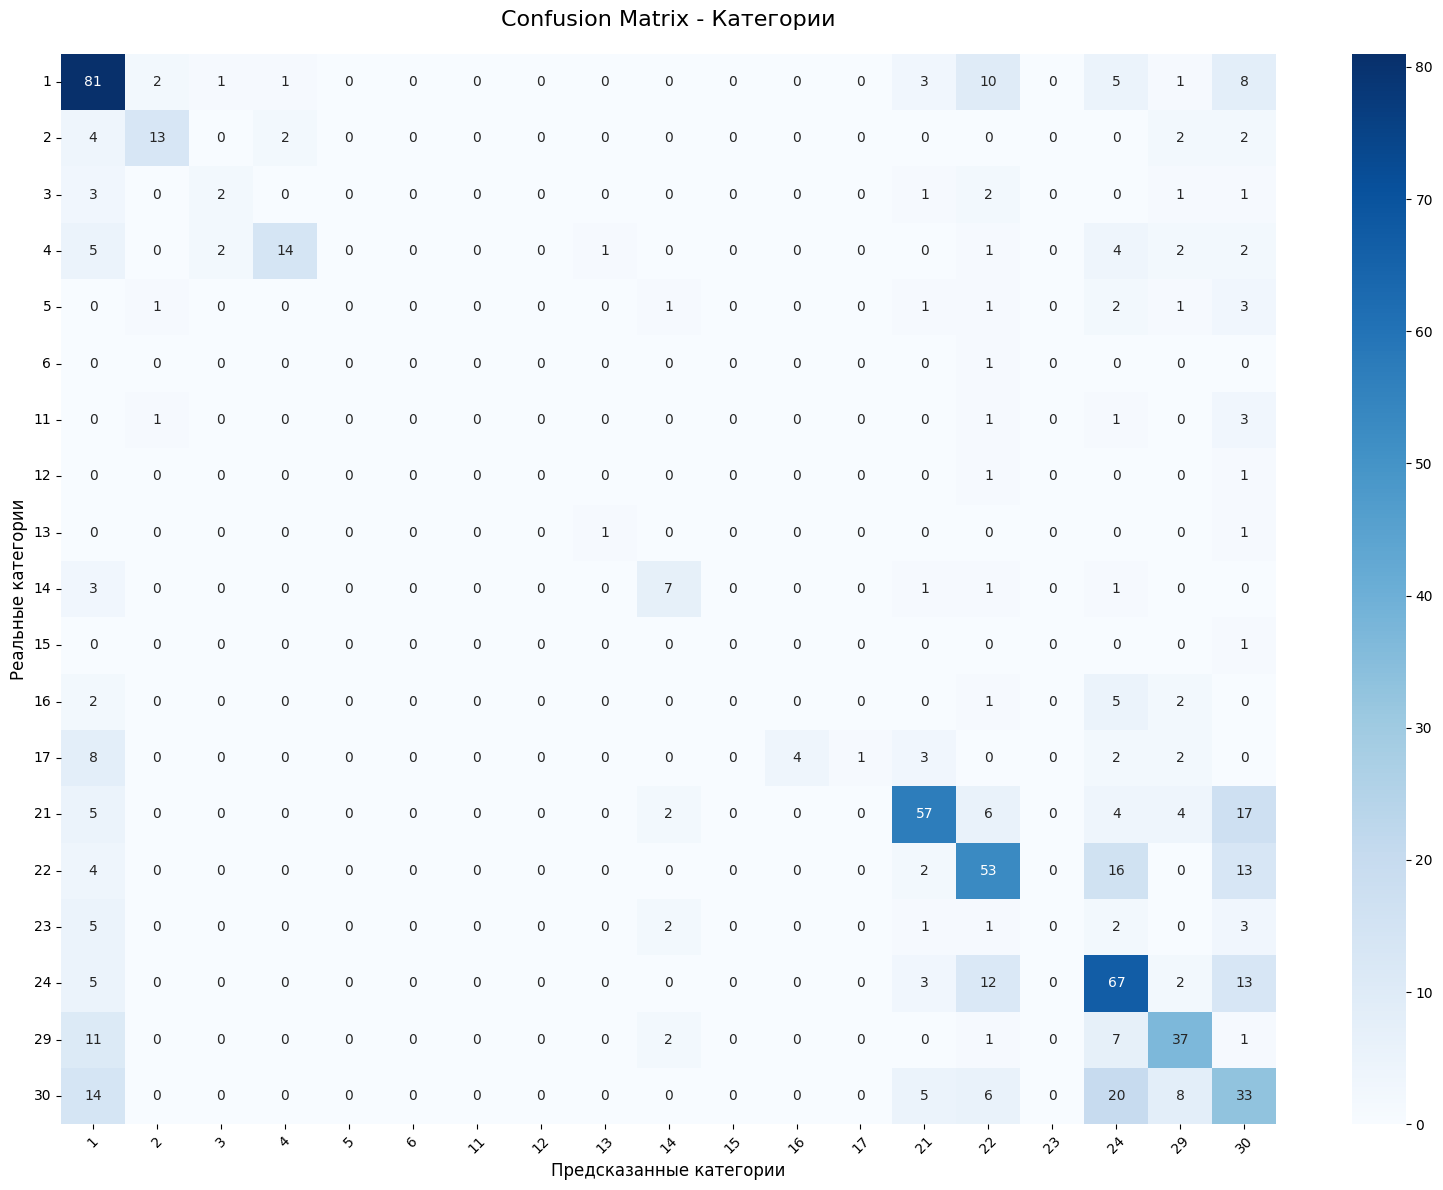

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Получаем реальные категории из данных
actual_categories = sorted(val_df['cat_id'].unique())
predicted_categories = sorted(np.unique(y_pred))
all_categories = sorted(set(actual_categories) | set(predicted_categories))

print(f"Реальные категории в val: {actual_categories}")
print(f"Предсказанные категории: {predicted_categories}")

# Создаем confusion matrix с правильными категориями
cm = confusion_matrix(val_df['cat_id'], y_pred, labels=all_categories)

# Отрисовываем с правильными labels
plt.figure(figsize=(16, 12))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=all_categories,
            yticklabels=all_categories)

plt.title('Confusion Matrix - Категории', fontsize=16, pad=20)
plt.xlabel('Предсказанные категории', fontsize=12)
plt.ylabel('Реальные категории', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Модель обучена на {len(model.classes_)} категориях: {model.classes_}")

Модель обучена на 25 категориях: [ 1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 20 21 22 23 24 25 29
 30]


In [ ]:
def predict_with_multiple_categories(model, texts, max_predictions=2, confidence_diff=0.1, min_confidence=0.3):
    """
    Предсказывает до max_predictions категорий для каждого текста
    """
    if isinstance(texts, str):
        texts = [texts]

    pool = Pool(texts, text_features=[0])
    predictions = model.predict(pool)
    probabilities = model.predict_proba(pool)

    results = []

    for i, text in enumerate(texts):
        text_results = []

        # Сортируем категории по уверенности
        cat_probs = list(enumerate(probabilities[i]))
        cat_probs.sort(key=lambda x: x[1], reverse=True)
        print('cat_probs', cat_probs)
        # Берем первую категорию (правильный маппинг через model.classes_)
        main_idx, main_conf = cat_probs[0]
        main_cat = model.classes_[main_idx]  # Правильный маппинг!
        text_results.append((main_cat, main_conf))

        # Проверяем условия для второй категории
        if ((len(cat_probs) > 1 or
            len(text.split()) > 8) and
            ',' in text and
            cat_probs[1][1] > min_confidence and
            main_conf - cat_probs[1][1] < confidence_diff):

            second_idx, second_conf = cat_probs[1]
            second_cat = model.classes_[second_idx]  # Правильный маппинг!
            text_results.append((second_cat, second_conf))

        results.append(text_results)

    return results

def aggregate_review_categories(review_sentences, model, sentence_weights=None):
    """
    Агрегирует категории по всему отзыву
    """
    if sentence_weights is None:
        sentence_weights = [1.0] * len(review_sentences)

    # Предсказываем категории для каждого предложения
    sentence_predictions = predict_with_multiple_categories(model, review_sentences)

    # Агрегируем scores по категориям
    category_scores = {}

    for i, preds in enumerate(sentence_predictions):
        weight = sentence_weights[i]

        for cat_id, confidence in preds:
            if cat_id not in category_scores:
                category_scores[cat_id] = 0
            category_scores[cat_id] += confidence * weight

    # Сортируем по убыванию score
    sorted_categories = sorted(category_scores.items(), key=lambda x: x[1], reverse=True)

    return sorted_categories

# Пример использования
def analyze_complete_review(review_text, model):
    """
    Анализирует полный отзыв и возвращает все значимые категории
    """
    # Разбиваем отзыв на предложения (упрощенно)
    sentences = [s.strip() for s in review_text.split('.') if s.strip()]
    #print('sentences', sentences)

    # Агрегируем категории
    category_scores = aggregate_review_categories(sentences, model)

    # Применяем порог (например, 0.5)
    significant_categories = [(cat_id, score) for cat_id, score in category_scores if score >= 0.5]

    return significant_categories

# Тестируем на примере
test_review = """
Приложение очень удобное, все функции работают стабильно.
Но в колл-центре постоянно долгое ожидание, операторы некомпетентны.
"""
#
#Кстати, условия по вкладам хорошие.

significant_cats = analyze_complete_review(test_review, model)
print("Значимые категории отзыва:")
for cat_id, score in significant_cats:
    print(f"Категория {cat_id}: score {score:.3f}")

cat_probs [(21, np.float64(0.4939962129318985)), (24, np.float64(0.21044518612899415)), (18, np.float64(0.11092500709926921)), (19, np.float64(0.08119628284830636)), (0, np.float64(0.02001405034489699)), (23, np.float64(0.018658610165720128)), (12, np.float64(0.014407716466357776)), (3, np.float64(0.007220360884252164)), (11, np.float64(0.007015479733611746)), (14, np.float64(0.006338356918813601)), (4, np.float64(0.006193211245495293)), (2, np.float64(0.005336611895813)), (1, np.float64(0.004723699124903736)), (20, np.float64(0.002842765511111928)), (13, np.float64(0.002831038819586743)), (17, np.float64(0.001998178576439539)), (16, np.float64(0.0018260420744472619)), (9, np.float64(0.001127926058829919)), (6, np.float64(0.0010973914044357773)), (15, np.float64(0.0008395625363158939)), (22, np.float64(0.00030256998756010903)), (10, np.float64(0.00027612480869826573)), (5, np.float64(0.00021531816271234044)), (7, np.float64(9.788702577366691e-05)), (8, np.float64(7.440924575596835e-05)

In [ ]:
CATEGORIES_D

{1: 'Дебетовые карты',
 2: 'Кредитные карты',
 3: 'Вклады',
 4: 'Накопительные счета',
 5: 'Потребительские кредиты',
 6: 'Автокредиты',
 7: 'Ипотека',
 8: 'Кредиты под залог недвижимости',
 9: 'Рефинансирование кредитов',
 10: 'Инвестиции',
 11: 'Страхование',
 12: 'Обмен валюты',
 13: 'Денежные переводы',
 14: 'Мобильный банк и приложение',
 15: 'Интернет-банк',
 16: 'Премиум-обслуживание',
 17: 'Газпром Бонус',
 18: 'ГПБ Мобайл',
 19: 'Банковские сейфы',
 20: 'Кредитная история и рейтинг',
 21: 'Работа колл-центра',
 22: 'Работа отделений',
 23: 'Безопасность',
 24: 'Общее впечатление о банке',
 25: 'Брокерский счет / ИИС',
 26: 'Сберегательные счета в металлах',
 27: 'Пенсионные продукты',
 28: 'Реструктуризация кредита',
 29: 'Кэшбэк, промокоды, бонусы, акции',
 30: 'прочее'}